In [1]:
from dataclasses import dataclass
from pathlib import Path
import numpy as np

@dataclass(frozen=True)
class Config:
    root: Path
    rates: tuple
    bws: tuple
    delays: tuple
    rate_map: dict
    kernels: tuple
    iterations: int

    @property
    def conditions(self) -> list[tuple]:
        return [(r, b, d, i) for r in self.rates for b in self.bws for d in self.delays for i in range(1, self.iterations + 1)]

    def get_rate_name(self, rate: int) -> str:
        return self.rate_map.get(rate, f'Rate{rate}')

    def base(self, rate: int, bw: str, delay: str, iteration: int) -> str:
        return f'rate{rate}_bw{bw}_delay{delay}_iter{iteration}'

    def dmesg_path(self, kernel: str, rate: int, bw: str, delay: str, iteration: int) -> Path:
        return self.root / kernel / 'debug' / 'dmesg' / f'debug_{self.base(rate, bw, delay, iteration)}.txt'

    def raw_path(self, kernel: str, rate: int, bw: str, delay: str, iteration: int) -> Path:
        return self.root / kernel / 'debug' / 'raw' / f'debug_{self.base(rate, bw, delay, iteration)}.json'

    def log_path(self, kernel: str) -> Path:
        return self.root / kernel / 'logs' / 'experiment.log'


config = Config(
    root=Path('../results/debug_test_modified').resolve(),
    rates=(64, 71, 199, 215),
    rate_map={
        64: 'HT20-SGI-MCS0', 71: 'HT20-SGI-MCS7', 199: 'HT20-SGI2-MCS7', 215: 'HT20-SGI2-MCS15'
    },
    kernels=('tcpaad2',),
    bws = ('nolim',),
    delays= ('nodelay', '50'),
    iterations=3
)

print('Project root:', config.root, config.root.exists())
print(f'Conditions: {len(config.conditions)}')

Project root: /home/rakhat/projects/TCP-AAD-Tests/results/debug_test_modified True
Conditions: 24


# PARSING DMESGES

In [2]:
import re
import pandas as pd
from datetime import datetime

def parse_timestamp(ts_str: str) -> datetime:
    ts_str = re.sub(r',(\d+)([+-]\d{2}:\d{2})$', r'.\1\2', ts_str)
    ts_str = ts_str.replace('T', ' ')
    for fmt in ('%Y-%m-%d %H:%M:%S.%f%z', '%Y-%m-%d %H:%M:%S%z'):
        try:
            return datetime.strptime(ts_str, fmt)
        except ValueError:
            continue
    return ts_str

_TS = re.compile(r'^(\S+)\s')

# ── Albert's feature_logs kernel (TCP_AAD only) ──────────────────────────────

# RECV subtypes
_RECV_NORMAL = re.compile(
    r'TCP_AAD RECV now_us=(\d+) sk=(\S+) seq=(\d+) end_seq=(\d+)'
    r' \| iat_curr=(\d+) iat_min=(\d+) ato_us=(\d+) ato_jiffies=(\d+) delayed_segs=(\d+)'
)
_RECV_IAT_RESET = re.compile(
    r'TCP_AAD RECV now_us=(\d+) sk=(\S+) seq=(\d+) end_seq=(\d+)'
    r' \| IAT_RESET old_iat_min=(\d+)'
)
_RECV_NOISE = re.compile(
    r'TCP_AAD RECV now_us=(\d+) sk=(\S+) seq=(\d+) end_seq=(\d+)'
    r' \| NOISE iat=(\d+) threshold=(\d+)'
)
_RECV_COLD_START = re.compile(
    r'TCP_AAD RECV now_us=(\d+) sk=(\S+) seq=(\d+) end_seq=(\d+) len=(\d+)'
    r' \| COLD_START delayed_segs=(\d+) ato_us=(\d+)'
)

# ACK_CHK subtypes
_ACK_CHK_ENTRY = re.compile(
    r'TCP_AAD ACK_CHK sk=(\S+) rcv_nxt=(\d+) ofo=(\d+) bytes=(\d+) mss=(\d+)'
    r' quick=(\d+) pingpong=(\d+) pending=(\S+) delayed_segs=(\d+)'
)
_ACK_CHK_DEFERRED = re.compile(
    r'TCP_AAD ACK_CHK sk=(\S+) rcv_nxt=(\d+) DEFERRED quick=(\d+)'
)
_ACK_CHK_SEND_NOW = re.compile(
    r'TCP_AAD ACK_CHK sk=(\S+) rcv_nxt=(\d+) SEND_NOW reason=(.*?)mss=(\d+)'
    r' quick=(\d+) pingpong=(-?\d+) pending=(\S+)'
)
_ACK_CHK_DELAYED = re.compile(
    r'TCP_AAD ACK_CHK sk=(\S+) rcv_nxt=(\d+) DELAYED quick=(\d+) pingpong=(\d+)'
    r' ato=(\d+) delayed_segs=(\d+)'
)
_ACK_CHK_COMPRESSED = re.compile(
    r'TCP_AAD ACK_CHK sk=(\S+) rcv_nxt=(\d+) COMPRESSED compressed_ack=(\d+) delay_ns=(\d+)'
)
_ACK_CHK_SKIP = re.compile(
    r'TCP_AAD ACK_CHK sk=(\S+) rcv_nxt=(\d+) SKIP pending=(\S+) quick=(\d+)'
)

# SCHED / ACK_SENT / TIMER
_SCHED = re.compile(
    r'TCP_AAD SCHED sk=(\S+) rcv_nxt=(\d+) ato_us=(\d+) ato_jiffies=(\d+) timeout_us=(\d+)'
)
_ACK_SENT = re.compile(
    r'TCP_AAD ACK_SENT sk=(\S+) rcv_nxt=(\d+)'
)
_TIMER_FIRED = re.compile(
    r'TCP_AAD TIMER_FIRED sk=(\S+) rcv_nxt=(\d+) pending=(\S+) quick=(\d+) delayed_segs=(\d+)'
)
_TIMER_ACK = re.compile(
    r'TCP_AAD TIMER_ACK sk=(\S+) rcv_nxt=(\d+) ato_before=(\d+) ato_after=(\d+)'
    r' pingpong=(\d+) quick=(\d+) delayed_segs=(\d+)'
)

# All known SEND_NOW reason flags emitted by the kernel
_SEND_NOW_FLAGS = ('TWO_SEG', 'QUICK', 'ACK_NOW', 'COMP_LIMIT', 'DUP_ACK')

EVENTS = ('recv', 'ack_chk', 'sched', 'timer_fired', 'timer_ack', 'ack_sent')

def parse_file(path, kernel, rate, bw, delay, iteration):
    rows = {ev: [] for ev in EVENTS}
    ctx = dict(kernel=kernel, rate=rate, bw=bw, delay=delay, iteration=iteration)

    with open(path) as f:
        for raw in f:
            line = raw.strip()
            if 'TCP_AAD' not in line:
                continue

            ts_m = _TS.match(line)
            if not ts_m:
                continue
            ts = parse_timestamp(ts_m.group(1))

            if ' RECV ' in line:
                m = _RECV_NORMAL.search(line)
                if m:
                    rows['recv'].append({**ctx, 'ts': ts,
                        'sk': m.group(2), 'now_us': int(m.group(1)),
                        'seq': int(m.group(3)), 'end_seq': int(m.group(4)),
                        'tag': 'NORMAL',
                        'iat_curr': int(m.group(5)), 'iat_min': int(m.group(6)),
                        'ato_us': int(m.group(7)), 'ato_jiffies': int(m.group(8)),
                        'delayed_segs': int(m.group(9)),
                    })
                    continue
                m = _RECV_IAT_RESET.search(line)
                if m:
                    rows['recv'].append({**ctx, 'ts': ts,
                        'sk': m.group(2), 'now_us': int(m.group(1)),
                        'seq': int(m.group(3)), 'end_seq': int(m.group(4)),
                        'tag': 'IAT_RESET', 'old_iat_min': int(m.group(5)),
                    })
                    continue
                m = _RECV_NOISE.search(line)
                if m:
                    rows['recv'].append({**ctx, 'ts': ts,
                        'sk': m.group(2), 'now_us': int(m.group(1)),
                        'seq': int(m.group(3)), 'end_seq': int(m.group(4)),
                        'tag': 'NOISE', 'iat': int(m.group(5)), 'threshold': int(m.group(6)),
                    })
                    continue
                m = _RECV_COLD_START.search(line)
                if m:
                    rows['recv'].append({**ctx, 'ts': ts,
                        'sk': m.group(2), 'now_us': int(m.group(1)),
                        'seq': int(m.group(3)), 'end_seq': int(m.group(4)),
                        'tag': 'COLD_START', 'len': int(m.group(5)),
                        'delayed_segs': int(m.group(6)), 'ato_us': int(m.group(7)),
                    })
                    continue

            elif ' ACK_CHK ' in line:
                # Check outcome subtypes first (they have keywords after rcv_nxt)
                m = _ACK_CHK_SEND_NOW.search(line)
                if m:
                    reason_str = m.group(3).strip()
                    row = {**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'outcome': 'SEND_NOW',
                        'reason': reason_str,
                        'mss': int(m.group(4)),
                        'quick': int(m.group(5)), 'pingpong': int(m.group(6)),
                        'pending': m.group(7),
                    }
                    # Parse individual reason flags into boolean columns
                    for flag in _SEND_NOW_FLAGS:
                        row[f'reason_{flag.lower()}'] = flag in reason_str
                    rows['ack_chk'].append(row)
                    continue
                m = _ACK_CHK_DELAYED.search(line)
                if m:
                    rows['ack_chk'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'outcome': 'DELAYED',
                        'quick': int(m.group(3)), 'pingpong': int(m.group(4)),
                        'ato': int(m.group(5)), 'delayed_segs': int(m.group(6)),
                    })
                    continue
                m = _ACK_CHK_DEFERRED.search(line)
                if m:
                    rows['ack_chk'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'outcome': 'DEFERRED', 'quick': int(m.group(3)),
                    })
                    continue
                m = _ACK_CHK_COMPRESSED.search(line)
                if m:
                    rows['ack_chk'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'outcome': 'COMPRESSED',
                        'compressed_ack': int(m.group(3)), 'delay_ns': int(m.group(4)),
                    })
                    continue
                m = _ACK_CHK_SKIP.search(line)
                if m:
                    rows['ack_chk'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'outcome': 'SKIP',
                        'pending': m.group(3), 'quick': int(m.group(4)),
                    })
                    continue
                # Entry diagnostic (no outcome keyword — has ofo= field)
                m = _ACK_CHK_ENTRY.search(line)
                if m:
                    rows['ack_chk'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'outcome': 'ENTRY',
                        'ofo': int(m.group(3)), 'bytes': int(m.group(4)),
                        'mss': int(m.group(5)), 'quick': int(m.group(6)),
                        'pingpong': int(m.group(7)), 'pending': m.group(8),
                        'delayed_segs': int(m.group(9)),
                    })
                    continue

            elif ' SCHED ' in line:
                m = _SCHED.search(line)
                if m:
                    rows['sched'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'ato_us': int(m.group(3)), 'ato_jiffies': int(m.group(4)),
                        'timeout_us': int(m.group(5)),
                    })

            elif ' TIMER_ACK ' in line:
                m = _TIMER_ACK.search(line)
                if m:
                    rows['timer_ack'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'ato_before': int(m.group(3)), 'ato_after': int(m.group(4)),
                        'pingpong': int(m.group(5)), 'quick': int(m.group(6)),
                        'delayed_segs': int(m.group(7)),
                    })

            elif ' TIMER_FIRED ' in line:
                m = _TIMER_FIRED.search(line)
                if m:
                    rows['timer_fired'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                        'pending': m.group(3), 'quick': int(m.group(4)),
                        'delayed_segs': int(m.group(5)),
                    })

            elif ' ACK_SENT ' in line:
                m = _ACK_SENT.search(line)
                if m:
                    rows['ack_sent'].append({**ctx, 'ts': ts,
                        'sk': m.group(1), 'rcv_nxt': int(m.group(2)),
                    })

    return rows

## `tcp_event_data_recv()` — Albert's feature_logs kernel

Called on every incoming data packet to update the delayed-ACK interval (ATO).
Uses hrtimer with microsecond precision. Fixed beta=1.5, fixed 200µs noise threshold, 1s hard reset for `iat_min`.

---

### `IAT_RESET`

`iat_min` exceeded 1s without update — hard-reset to `U64_MAX` and re-converge.

```
TCP_AAD RECV now_us=%llu sk=%p seq=%u end_seq=%u | IAT_RESET old_iat_min=%u
```

| Field | Meaning |
|---|---|
| `sk` | socket pointer |
| `seq` / `end_seq` | sequence range |
| `now_us` | current time (µs) |
| `old_iat_min` | previous `iat_min` before reset |

---

### `NOISE`

Packet ignored — IAT below fixed 200µs noise threshold.

```
TCP_AAD RECV now_us=%llu sk=%p seq=%u end_seq=%u | NOISE iat=%lu threshold=200
```

| Field | Meaning |
|---|---|
| `iat` | current inter-arrival time (µs) |
| `threshold` | fixed at 200µs |

---

### `COLD_START`

`delayed_segs < 2` — not enough samples yet. ATO set to 500ms fallback.

```
TCP_AAD RECV now_us=%llu sk=%p seq=%u end_seq=%u len=%u | COLD_START delayed_segs=%u ato_us=%lu
```

| Field | Meaning |
|---|---|
| `len` | segment length |
| `delayed_segs` | segments delayed so far (0 or 1) |
| `ato_us` | fallback ATO (500ms) |

---

### Normal (no tag)

Normal ATO computation: `ato = iat_min * beta` where beta=1.5.

```
TCP_AAD RECV now_us=%llu sk=%p seq=%u end_seq=%u | iat_curr=%lu iat_min=%u ato_us=%lu ato_jiffies=%u delayed_segs=%u
```

| Field | Meaning |
|---|---|
| `iat_curr` | current inter-arrival time (µs) |
| `iat_min` | running minimum IAT (µs) |
| `ato_us` | computed ATO (µs) |
| `ato_jiffies` | ATO converted to jiffies (for comparison with jiffies-based kernel) |
| `delayed_segs` | segments delayed so far |

## `tcp_ack_snd_check()` / `__tcp_ack_snd_check()`

Called after every received segment to decide whether to ACK now, delay, or skip.

---

### `ENTRY` (diagnostic)

Fires at the top of `__tcp_ack_snd_check()` before any decision.

```
TCP_AAD ACK_CHK sk=%p rcv_nxt=%u ofo=%d bytes=%u mss=%u quick=%u pingpong=%d pending=%x delayed_segs=%u
```

| Field | Meaning |
|---|---|
| `ofo` | out-of-order possible (1 = yes) |
| `bytes` | unacked bytes received (`rcv_nxt - rcv_wup`) |
| `mss` | receiver MSS estimate |
| `quick` | quickack counter |
| `pingpong` | 1 = bidirectional flow |
| `pending` | `icsk_ack.pending` flags |
| `delayed_segs` | segments delayed so far |

---

### `SEND_NOW`

Send ACK immediately. The `reason` field contains one or more flags indicating which condition(s) triggered it.

```
TCP_AAD ACK_CHK sk=%p rcv_nxt=%u SEND_NOW reason=%s%s%s%s%s mss=%u quick=%u pingpong=%d pending=%x
```

| Field | Meaning |
|---|---|
| `reason` | space-separated flags: `TWO_SEG`, `QUICK`, `ACK_NOW`, `COMP_LIMIT`, `DUP_ACK` |
| `mss` | receiver MSS estimate |
| `quick` | quickack counter |
| `pingpong` | 1 = bidirectional |
| `pending` | pending flags |

Reason flags:
- `TWO_SEG` — two-segment rule (RFC 5681): `rcv_nxt - rcv_wup > mss`
- `QUICK` — quickack mode active (`quick > 0`)
- `ACK_NOW` — protocol-mandated (`ICSK_ACK_NOW` set)
- `COMP_LIMIT` — compressed ACK threshold exceeded or SACK disabled
- `DUP_ACK` — duplicate ACK counter below fast retransmit threshold

---

### `DEFERRED`

Socket owned by user — defer ACK to `tcp_release_cb()`.

```
TCP_AAD ACK_CHK sk=%p rcv_nxt=%u DEFERRED quick=%u
```

---

### `DELAYED`

Schedule delayed ACK via `tcp_send_delayed_ack()`.

```
TCP_AAD ACK_CHK sk=%p rcv_nxt=%u DELAYED quick=%u pingpong=%d ato=%lu delayed_segs=%u
```

| Field | Meaning |
|---|---|
| `ato` | current ATO (jiffies) |
| `delayed_segs` | segments delayed so far |

---

### `COMPRESSED`

OOO + SACK — suppress ACK, arm compressed-ACK hrtimer.

```
TCP_AAD ACK_CHK sk=%p rcv_nxt=%u COMPRESSED compressed_ack=%d delay_ns=%lu
```

| Field | Meaning |
|---|---|
| `compressed_ack` | ACKs compressed so far |
| `delay_ns` | hrtimer delay (nanoseconds) |

---

### `SKIP`

ACK not scheduled — data segment already carries implicit ACK.

```
TCP_AAD ACK_CHK sk=%p rcv_nxt=%u SKIP pending=%x quick=%u
```

## `tcp_send_delayed_ack()`

### `SCHED`

Timer armed — delayed ACK scheduled.

```
TCP_AAD SCHED sk=%p rcv_nxt=%u ato_us=%lu ato_jiffies=%lu timeout_us=%lu
```

| Field | Meaning |
|---|---|
| `ato_us` | ATO value in microseconds (hrtimer precision) |
| `ato_jiffies` | same ATO converted to jiffies (for comparison with jiffies kernel) |
| `timeout_us` | actual timer timeout in microseconds |

## `tcp_delack_timer_handler()` / `tcp_delack_hrtimer()`

### `TIMER_FIRED` (entry diagnostic)

```
TCP_AAD TIMER_FIRED sk=%p rcv_nxt=%u pending=%x quick=%u delayed_segs=%u
```

| Field | Meaning |
|---|---|
| `pending` | `icsk_ack.pending` flags |
| `quick` | quickack counter |
| `delayed_segs` | segments delayed when timer fired |

---

### `TIMER_ACK`

Timer expired, ACK sent, ATO adjusted.

```
TCP_AAD TIMER_ACK sk=%p rcv_nxt=%u ato_before=%lu ato_after=%lu pingpong=%d quick=%u delayed_segs=%u
```

| Field | Meaning |
|---|---|
| `ato_before` | ATO before adjustment |
| `ato_after` | ATO after adjustment (doubled up to RTO, or reset on pingpong exit) |
| `pingpong` | 1 = was in pingpong mode |
| `quick` | quickack counter |
| `delayed_segs` | segments delayed |

## `tcp_send_ack()`

```
TCP_AAD ACK_SENT sk=%p rcv_nxt=%u
```

| Field | Meaning |
|---|---|
| `sk` | socket pointer |
| `rcv_nxt` | sequence number being ACKed |

In [3]:
all_rows = {k: {ev: [] for ev in EVENTS} for k in config.kernels}

for kernel in config.kernels:
    for rate, bw, delay, iteration in config.conditions:
        path = config.dmesg_path(kernel, rate, bw, delay, iteration)
        if not path.exists():
            print(f'MISSING: {path}')
            continue
        file_rows = parse_file(path, kernel, rate, bw, delay, iteration)
        for ev in EVENTS:
            all_rows[kernel][ev].extend(file_rows[ev])

dfs = {
    kernel: {ev: pd.DataFrame(all_rows[kernel][ev]) for ev in EVENTS}
    for kernel in config.kernels
}

for kernel in config.kernels:
    print(f'\n{kernel}:')
    for ev in EVENTS:
        print(f'  {ev}: {len(dfs[kernel][ev])} rows')
    # Show RECV tag distribution
    recv_df = dfs[kernel]['recv']
    if not recv_df.empty and 'tag' in recv_df.columns:
        print(f'  recv tags: {recv_df["tag"].value_counts().to_dict()}')
    # Show ACK_CHK outcome distribution
    ack_df = dfs[kernel]['ack_chk']
    if not ack_df.empty and 'outcome' in ack_df.columns:
        print(f'  ack_chk outcomes: {ack_df["outcome"].value_counts().to_dict()}')


tcpaad2:
  recv: 1654136 rows
  ack_chk: 1941602 rows
  sched: 439867 rows
  timer_fired: 41 rows
  timer_ack: 40 rows
  ack_sent: 563716 rows
  recv tags: {'COLD_START': 824587, 'NOISE': 787128, 'NORMAL': 41768, 'IAT_RESET': 653}
  ack_chk outcomes: {'ENTRY': 963789, 'SEND_NOW': 523482, 'DELAYED': 439867, 'SKIP': 14024, 'DEFERRED': 440}


# PLOTS

In [4]:
# import numpy as np
import matplotlib
import matplotlib.pyplot as plt

PLOT_COLORS = ('#1f77b4', '#ff7f0e', '#2ca02c', '#AA4A44', '#CBC3E3')
FONT_SIZES  = {'small': 14, 'medium': 20, 'large': 24}

matplotlib.rcParams.update({
    'figure.figsize':   (16, 5),
    'figure.titlesize': FONT_SIZES['large'],
    'font.size':        FONT_SIZES['small'],
    'axes.labelsize':   FONT_SIZES['medium'],
    'axes.titlesize':   FONT_SIZES['medium'],
    'xtick.labelsize':  FONT_SIZES['small'],
    'ytick.labelsize':  FONT_SIZES['small'],
    'legend.fontsize':  FONT_SIZES['small'],
})

In [5]:
RATE, BW, DELAY, ITER = 199, 'nolim', 'nodelay', 1

_f = lambda df: df[(df['rate']==RATE)&(df['bw']==BW)&(df['delay']==DELAY)&(df['iteration']==ITER)]

# 1. SEND_NOW Decomposition

Which condition triggers immediate ACKs? The kernel emits reason flags directly:
- `TWO_SEG` — two-segment rule (RFC 5681): `rcv_nxt - rcv_wup > mss`
- `QUICK` — quickack mode active
- `ACK_NOW` — protocol-mandated (`ICSK_ACK_NOW`)
- `COMP_LIMIT` — compressed ACK threshold exceeded or SACK disabled
- `DUP_ACK` — duplicate ACK counter below fast retransmit threshold

In [6]:
kernel = 'tcpaad2'
send_now = dfs[kernel]['ack_chk'][dfs[kernel]['ack_chk']['outcome'] == 'SEND_NOW'].copy()

# The kernel now emits reason flags directly — no reconstruction needed.
# Each row has boolean columns: reason_two_seg, reason_quick, reason_ack_now, reason_comp_limit, reason_dup_ack
# Cast to bool arrays (columns come from heterogeneous DataFrame so dtype may be object)
flag_cols = [c for c in send_now.columns if c.startswith('reason_')]
for col in flag_cols:
    send_now[col] = send_now[col].astype(bool)

# Primary trigger: first matching flag in kernel evaluation order
conditions = [
    send_now['reason_two_seg'].values,
    send_now['reason_quick'].values,
    send_now['reason_ack_now'].values,
    send_now['reason_comp_limit'].values,
    send_now['reason_dup_ack'].values,
]
choices = ['TWO_SEG', 'QUICK', 'ACK_NOW', 'COMP_LIMIT', 'DUP_ACK']
send_now['trigger'] = np.select(conditions, choices, default='UNKNOWN')

# Show how many rows have multiple reason flags set
multi = send_now[flag_cols].sum(axis=1)
print(f"=== Rows with multiple reason flags: {(multi > 1).sum()} / {len(send_now)} ===\n")

print("=== SEND_NOW trigger breakdown (primary trigger) ===")
trigger_counts = send_now['trigger'].value_counts()
trigger_total = len(send_now)
for trigger, count in trigger_counts.items():
    print(f"  {trigger:20s}: {count:>8d}  ({count/trigger_total*100:5.1f}%)")
print(f"  {'TOTAL':20s}: {trigger_total:>8d}")

# Per-flag breakdown (flags are not mutually exclusive)
print("\n=== SEND_NOW per-flag counts (non-exclusive) ===")
for flag in _SEND_NOW_FLAGS:
    col = f'reason_{flag.lower()}'
    if col in send_now.columns:
        count = send_now[col].sum()
        print(f"  {flag:20s}: {count:>8d}  ({count/trigger_total*100:5.1f}%)")

print("\n=== SEND_NOW trigger breakdown per rate ===")
for rate in sorted(send_now['rate'].unique()):
    rate_df = send_now[send_now['rate'] == rate]
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    print(f"\n  {rate_name} (rate={rate}, n={len(rate_df)}):")
    for trigger, count in rate_df['trigger'].value_counts().items():
        print(f"    {trigger:20s}: {count:>8d}  ({count/len(rate_df)*100:5.1f}%)")

print("\n=== SEND_NOW trigger breakdown per delay ===")
for delay in sorted(send_now['delay'].unique()):
    delay_df = send_now[send_now['delay'] == delay]
    print(f"\n  delay={delay} (n={len(delay_df)}):")
    for trigger, count in delay_df['trigger'].value_counts().items():
        print(f"    {trigger:20s}: {count:>8d}  ({count/len(delay_df)*100:5.1f}%)")

=== Rows with multiple reason flags: 127 / 523482 ===

=== SEND_NOW trigger breakdown (primary trigger) ===
  TWO_SEG             :   397644  ( 76.0%)
  COMP_LIMIT          :    99653  ( 19.0%)
  QUICK               :    26051  (  5.0%)
  ACK_NOW             :      134  (  0.0%)
  TOTAL               :   523482

=== SEND_NOW per-flag counts (non-exclusive) ===
  TWO_SEG             :   397644  ( 76.0%)
  QUICK               :    26163  (  5.0%)
  ACK_NOW             :      158  (  0.0%)
  COMP_LIMIT          :    99653  ( 19.0%)
  DUP_ACK             :        0  (  0.0%)

=== SEND_NOW trigger breakdown per rate ===

  HT20-SGI-MCS0 (rate=64, n=16798):
    TWO_SEG             :    12280  ( 73.1%)
    COMP_LIMIT          :     2964  ( 17.6%)
    QUICK               :     1484  (  8.8%)
    ACK_NOW             :       70  (  0.4%)

  HT20-SGI-MCS7 (rate=71, n=118570):
    TWO_SEG             :    83457  ( 70.4%)
    COMP_LIMIT          :    27083  ( 22.8%)
    QUICK               :     80

# 2. ATO Distribution — hrtimer vs jiffies

From the NORMAL recv events where the formula actually ran.
Compare `ato_us` (hrtimer precision) with `ato_jiffies` (what a jiffies kernel would use).
At HZ=1000, 1 jiffy = 1ms. If most ATOs are < 1ms, they all collapse to 1 jiffy.

In [7]:
recv_df = dfs[kernel]['recv']
normal = recv_df[recv_df['tag'] == 'NORMAL'].copy()

print(f"=== ATO from NORMAL recv events (n={len(normal)}) ===\n")

print("ato_us statistics (microseconds):")
print(normal['ato_us'].describe().to_string())

print(f"\nato_jiffies distribution:")
jiffies_counts = normal['ato_jiffies'].value_counts().sort_index()
for jif, count in jiffies_counts.items():
    print(f"  {int(jif)} jiffies ({int(jif)}ms): {count:>8d}  ({count/len(normal)*100:5.1f}%)")

pct_1_jiffy = (normal['ato_jiffies'] <= 1).sum() / len(normal) * 100
print(f"\n% of ATOs that collapse to ≤1 jiffy: {pct_1_jiffy:.1f}%")

=== ATO from NORMAL recv events (n=41768) ===

ato_us statistics (microseconds):
count     41768.000000
mean       7843.160530
std       42507.214104
min         301.000000
25%         363.000000
50%         884.000000
75%        2130.000000
max      500000.000000

ato_jiffies distribution:
  1 jiffies (1ms):    22949  ( 54.9%)
  2 jiffies (2ms):     7904  ( 18.9%)
  3 jiffies (3ms):     3151  (  7.5%)
  4 jiffies (4ms):      417  (  1.0%)
  5 jiffies (5ms):      201  (  0.5%)
  6 jiffies (6ms):      325  (  0.8%)
  7 jiffies (7ms):      630  (  1.5%)
  8 jiffies (8ms):      446  (  1.1%)
  9 jiffies (9ms):      402  (  1.0%)
  10 jiffies (10ms):      324  (  0.8%)
  11 jiffies (11ms):      315  (  0.8%)
  12 jiffies (12ms):      315  (  0.8%)
  13 jiffies (13ms):      261  (  0.6%)
  14 jiffies (14ms):      258  (  0.6%)
  15 jiffies (15ms):      231  (  0.6%)
  16 jiffies (16ms):      240  (  0.6%)
  17 jiffies (17ms):      181  (  0.4%)
  18 jiffies (18ms):      154  (  0.4%)
  19 j

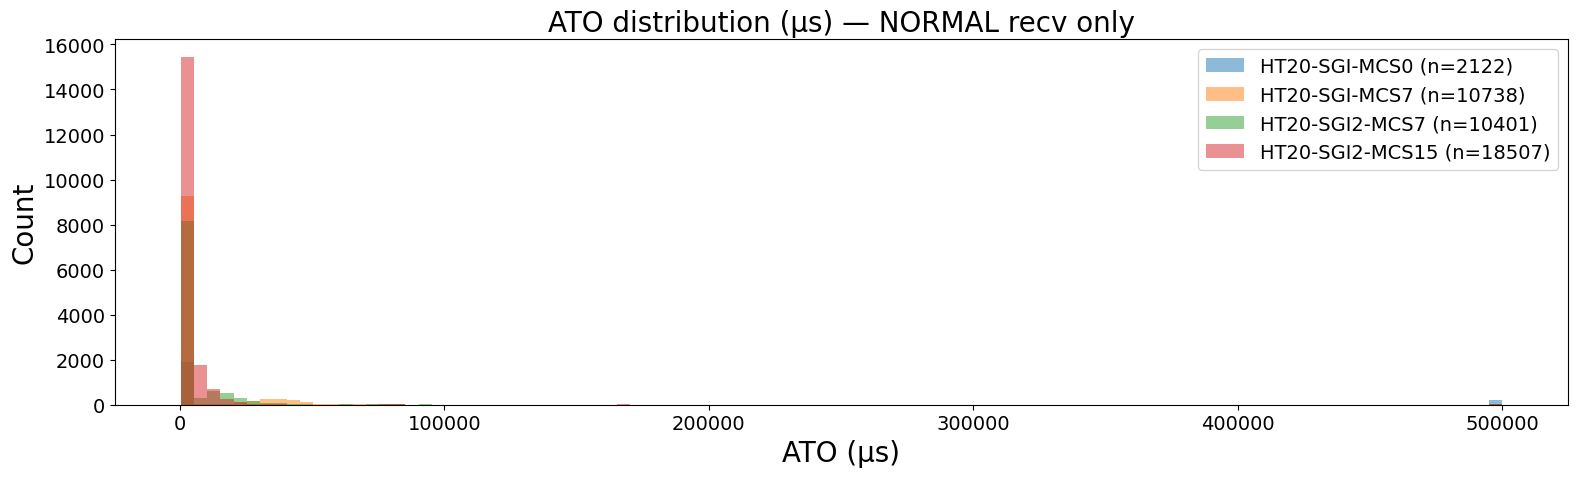

In [8]:
# ATO (µs) histogram per rate — full width, one plot
fig, ax = plt.subplots(figsize=(16, 5))
for rate in sorted(normal['rate'].unique()):
    rate_data = normal[normal['rate'] == rate]['ato_us']
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    ax.hist(rate_data, bins=100, alpha=0.5, label=f'{rate_name} (n={len(rate_data)})')
ax.set_xlabel('ATO (µs)')
ax.set_ylabel('Count')
ax.set_title('ATO distribution (µs) — NORMAL recv only')
ax.legend()
plt.tight_layout()
plt.show()

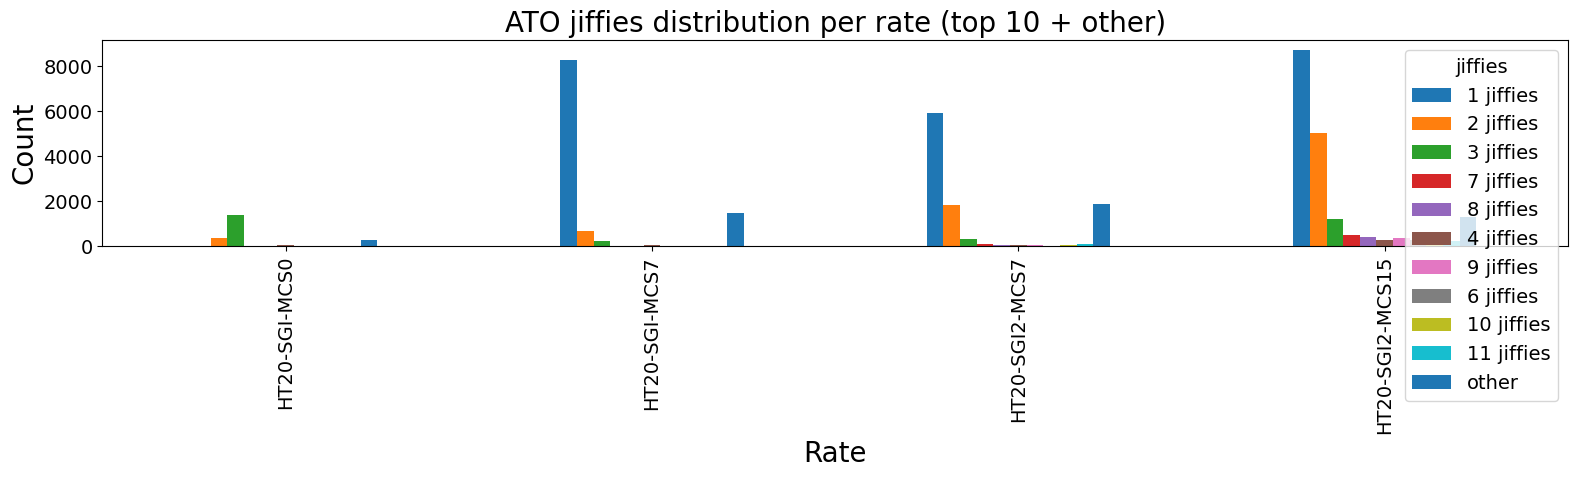

In [9]:
# ATO jiffies distribution per rate — group rare values to keep legend readable
TOP_N_JIFFIES = 10

jiffies_by_rate = normal.groupby(['rate', 'ato_jiffies']).size().unstack(fill_value=0)

# Keep top N jiffies values by total count, lump the rest into "other"
col_totals = jiffies_by_rate.sum(axis=0).sort_values(ascending=False)
top_cols = col_totals.head(TOP_N_JIFFIES).index
other_cols = col_totals.index.difference(top_cols)

jiffies_grouped = jiffies_by_rate[top_cols].copy()
if len(other_cols) > 0:
    jiffies_grouped['other'] = jiffies_by_rate[other_cols].sum(axis=1)

# Rename index to rate names
jiffies_grouped.index = [config.rate_map.get(r, f'Rate{r}') for r in jiffies_grouped.index]
# Rename columns to "N jiffies"
jiffies_grouped.columns = [f'{int(c)} jiffies' if c != 'other' else 'other' for c in jiffies_grouped.columns]

fig, ax = plt.subplots(figsize=(16, 5))
jiffies_grouped.plot(kind='bar', ax=ax)
ax.set_xlabel('Rate')
ax.set_ylabel('Count')
ax.set_title(f'ATO jiffies distribution per rate (top {TOP_N_JIFFIES} + other)')
ax.legend(title='jiffies', loc='upper right')
plt.tight_layout()
plt.show()

In [10]:
# SCHED event ATO statistics
sched_df = dfs[kernel]['sched']
print(f"=== SCHED ato_us statistics (n={len(sched_df)}) ===")
print(sched_df['ato_us'].describe().to_string())
print(f"\n% of SCHED ato_jiffies ≤ 1: {(sched_df['ato_jiffies'] <= 1).sum() / len(sched_df) * 100:.1f}%")

=== SCHED ato_us statistics (n=439867) ===
count    439867.000000
mean     486079.312713
std       81286.096387
min         304.000000
25%      500000.000000
50%      500000.000000
75%      500000.000000
max      500000.000000

% of SCHED ato_jiffies ≤ 1: 0.5%


# 3. Per-Rate Breakdown

How does the RECV tag and ACK_CHK outcome distribution vary across MCS rates?

=== RECV tag distribution per rate ===

HT20-SGI-MCS0 (rate=64, n=28523):
  COLD_START     :    26135  ( 91.6%)
  NORMAL         :     2122  (  7.4%)
  IAT_RESET      :      168  (  0.6%)
  NOISE          :       98  (  0.3%)

HT20-SGI-MCS7 (rate=71, n=354954):
  COLD_START     :   175569  ( 49.5%)
  NOISE          :   168477  ( 47.5%)
  NORMAL         :    10738  (  3.0%)
  IAT_RESET      :      170  (  0.0%)

HT20-SGI2-MCS7 (rate=199, n=542375):
  COLD_START     :   268311  ( 49.5%)
  NOISE          :   263502  ( 48.6%)
  NORMAL         :    10401  (  1.9%)
  IAT_RESET      :      161  (  0.0%)

HT20-SGI2-MCS15 (rate=215, n=728284):
  NOISE          :   355051  ( 48.8%)
  COLD_START     :   354572  ( 48.7%)
  NORMAL         :    18507  (  2.5%)
  IAT_RESET      :      154  (  0.0%)


=== ACK_CHK outcome distribution per rate ===

HT20-SGI-MCS0 (rate=64, n=33907):
  SEND_NOW       :    16798  ( 49.5%)
  DELAYED        :    14523  ( 42.8%)
  SKIP           :     2585  (  7.6%)
  DEFERR

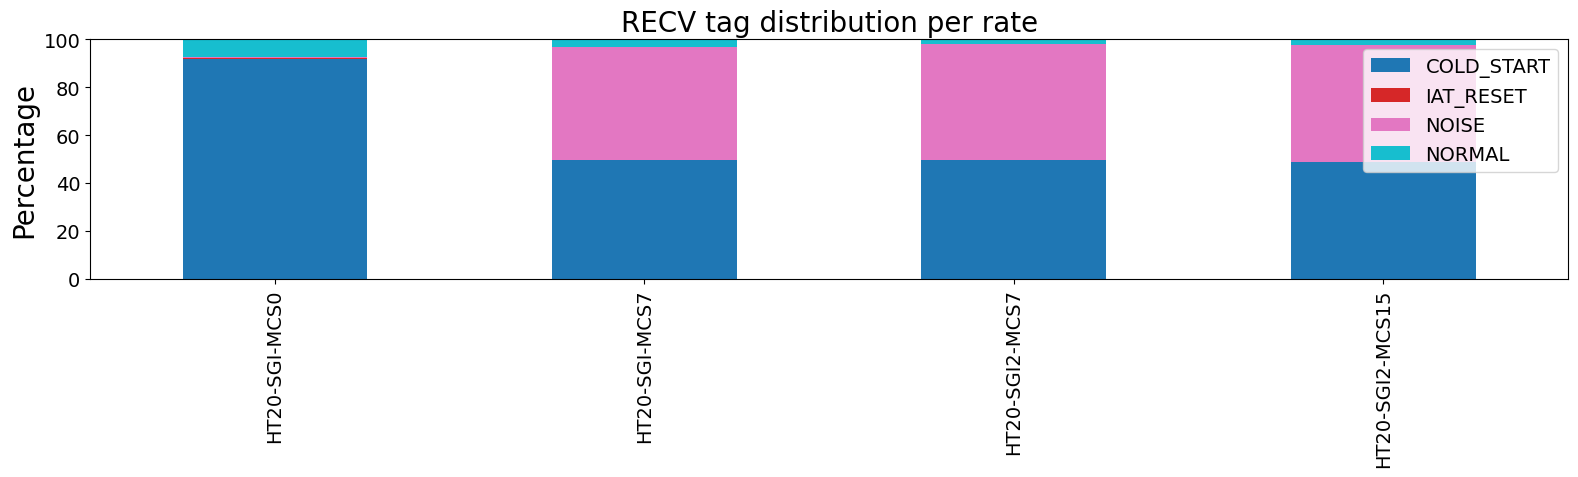

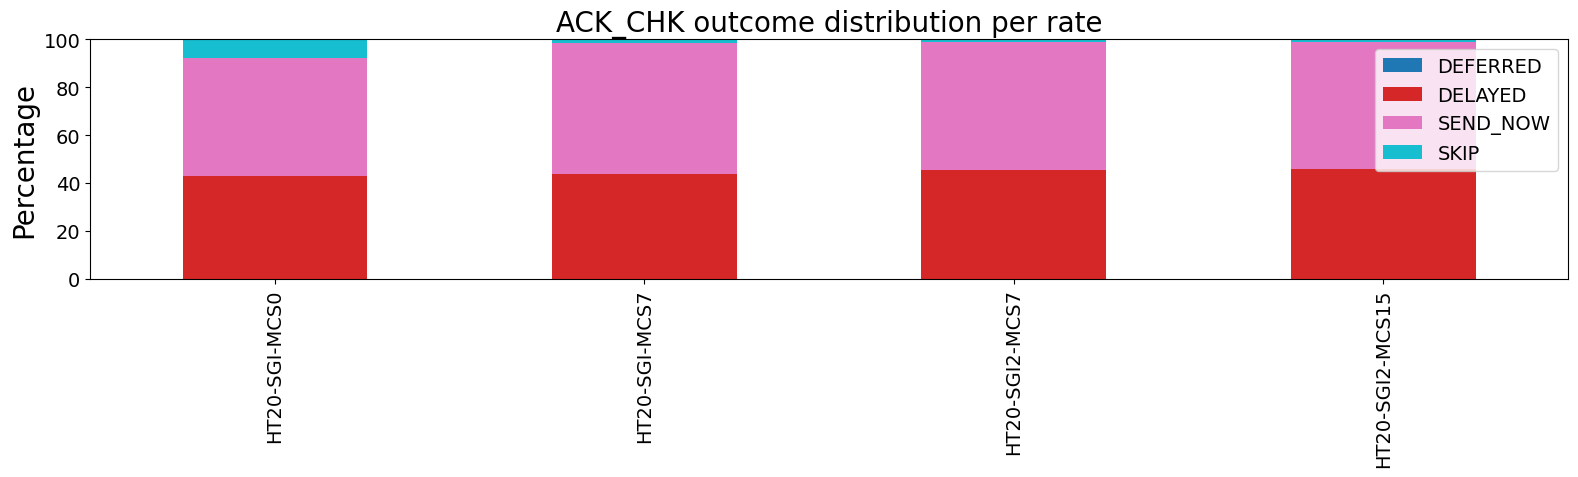

In [11]:
recv_df = dfs['tcpaad2']['recv']
ack_df = dfs['tcpaad2']['ack_chk']

# Filter to non-ENTRY ack_chk (actual decisions)
decisions = ack_df[ack_df['outcome'] != 'ENTRY']

print("=== RECV tag distribution per rate ===\n")
for rate in sorted(recv_df['rate'].unique()):
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    r = recv_df[recv_df['rate'] == rate]
    total = len(r)
    print(f"{rate_name} (rate={rate}, n={total}):")
    for tag, count in r['tag'].value_counts().items():
        print(f"  {tag:15s}: {count:>8d}  ({count/total*100:5.1f}%)")
    print()

print("\n=== ACK_CHK outcome distribution per rate ===\n")
for rate in sorted(decisions['rate'].unique()):
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    r = decisions[decisions['rate'] == rate]
    total = len(r)
    print(f"{rate_name} (rate={rate}, n={total}):")
    for outcome, count in r['outcome'].value_counts().items():
        print(f"  {outcome:15s}: {count:>8d}  ({count/total*100:5.1f}%)")
    print()

# RECV tags per rate — full width
recv_pivot = recv_df.groupby(['rate', 'tag']).size().unstack(fill_value=0)
recv_pivot.index = [config.rate_map.get(r, f'Rate{r}') for r in recv_pivot.index]
recv_pct = recv_pivot.div(recv_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
recv_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_ylabel('Percentage')
ax.set_title('RECV tag distribution per rate')
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# ACK_CHK outcomes per rate — full width
ack_pivot = decisions.groupby(['rate', 'outcome']).size().unstack(fill_value=0)
ack_pivot.index = [config.rate_map.get(r, f'Rate{r}') for r in ack_pivot.index]
ack_pct = ack_pivot.div(ack_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ack_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_ylabel('Percentage')
ax.set_title('ACK_CHK outcome distribution per rate')
ax.legend(loc='upper right')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# 4. Per-Delay Breakdown

Does adding 50ms RTT change the SEND_NOW ratio or ATO values?

In [12]:
recv_df = dfs['tcpaad2']['recv']
ack_df = dfs['tcpaad2']['ack_chk']
decisions = ack_df[ack_df['outcome'] != 'ENTRY']

print("=== RECV tag distribution per delay ===\n")
for delay in sorted(recv_df['delay'].unique()):
    r = recv_df[recv_df['delay'] == delay]
    total = len(r)
    print(f"delay={delay} (n={total}):")
    for tag, count in r['tag'].value_counts().items():
        print(f"  {tag:15s}: {count:>8d}  ({count/total*100:5.1f}%)")
    print()

print("=== ACK_CHK outcome distribution per delay ===\n")
for delay in sorted(decisions['delay'].unique()):
    r = decisions[decisions['delay'] == delay]
    total = len(r)
    print(f"delay={delay} (n={total}):")
    for outcome, count in r['outcome'].value_counts().items():
        print(f"  {outcome:15s}: {count:>8d}  ({count/total*100:5.1f}%)")
    print()

# ATO comparison: nodelay vs 50ms
normal = recv_df[recv_df['tag'] == 'NORMAL']
print("=== ATO (µs) from NORMAL recv — nodelay vs 50ms ===\n")
for delay in sorted(normal['delay'].unique()):
    delay_normal = normal[normal['delay'] == delay]
    ato = delay_normal['ato_us']
    pct_1j = (delay_normal['ato_jiffies'] <= 1).sum() / len(delay_normal) * 100
    print(f"delay={delay} (n={len(delay_normal)}):")
    print(f"  mean={ato.mean():.0f}  median={ato.median():.0f}  p5={ato.quantile(0.05):.0f}  p95={ato.quantile(0.95):.0f}")
    print(f"  ato_jiffies ≤ 1: {pct_1j:.1f}%")
    print()

=== RECV tag distribution per delay ===

delay=50 (n=229365):
  COLD_START     :   116086  ( 50.6%)
  NOISE          :   100631  ( 43.9%)
  NORMAL         :    12343  (  5.4%)
  IAT_RESET      :      305  (  0.1%)

delay=nodelay (n=1424771):
  COLD_START     :   708501  ( 49.7%)
  NOISE          :   686497  ( 48.2%)
  NORMAL         :    29425  (  2.1%)
  IAT_RESET      :      348  (  0.0%)

=== ACK_CHK outcome distribution per delay ===

delay=50 (n=202713):
  SEND_NOW       :   132095  ( 65.2%)
  DELAYED        :    63082  ( 31.1%)
  SKIP           :     7293  (  3.6%)
  DEFERRED       :      243  (  0.1%)

delay=nodelay (n=775100):
  SEND_NOW       :   391387  ( 50.5%)
  DELAYED        :   376785  ( 48.6%)
  SKIP           :     6731  (  0.9%)
  DEFERRED       :      197  (  0.0%)

=== ATO (µs) from NORMAL recv — nodelay vs 50ms ===

delay=50 (n=12343):
  mean=10972  median=501  p5=304  p95=43095
  ato_jiffies ≤ 1: 70.8%

delay=nodelay (n=29425):
  mean=6531  median=1068  p5=319  p9

# 5. delayed_segs Lifecycle

Does the counter ever climb above 1? COLD_START fires when `delayed_segs < 2`.
If SEND_NOW keeps resetting it to 0, the formula never runs.

In [13]:
recv_df = dfs['tcpaad2']['recv']
ack_df = dfs['tcpaad2']['ack_chk']

# delayed_segs from COLD_START events
cold = recv_df[recv_df['tag'] == 'COLD_START']
print(f"=== COLD_START delayed_segs distribution (n={len(cold)}) ===")
cs_counts = cold['delayed_segs'].value_counts().sort_index()
for val, count in cs_counts.items():
    print(f"  delayed_segs={int(val)}: {count:>8d}  ({count/len(cold)*100:5.1f}%)")

# delayed_segs from DELAYED events (when an ACK is actually delayed)
delayed = ack_df[ack_df['outcome'] == 'DELAYED']
print(f"\n=== DELAYED ack_chk delayed_segs distribution (n={len(delayed)}) ===")
d_counts = delayed['delayed_segs'].value_counts().sort_index()
for val, count in d_counts.head(20).items():
    print(f"  delayed_segs={int(val)}: {count:>8d}  ({count/len(delayed)*100:5.1f}%)")
if len(d_counts) > 20:
    print(f"  ... ({len(d_counts)} unique values total)")

# delayed_segs from ENTRY events
entry = ack_df[ack_df['outcome'] == 'ENTRY']
print(f"\n=== ENTRY ack_chk delayed_segs distribution (n={len(entry)}) ===")
e_counts = entry['delayed_segs'].value_counts().sort_index()
for val, count in e_counts.head(20).items():
    print(f"  delayed_segs={int(val)}: {count:>8d}  ({count/len(entry)*100:5.1f}%)")
if len(e_counts) > 20:
    print(f"  ... ({len(e_counts)} unique values total)")

# delayed_segs from NORMAL recv (formula actually ran)
normal = recv_df[recv_df['tag'] == 'NORMAL']
print(f"\n=== NORMAL recv delayed_segs distribution (n={len(normal)}) ===")
n_counts = normal['delayed_segs'].value_counts().sort_index()
for val, count in n_counts.head(20).items():
    print(f"  delayed_segs={int(val)}: {count:>8d}  ({count/len(normal)*100:5.1f}%)")
if len(n_counts) > 20:
    print(f"  ... ({len(n_counts)} unique values total)")

print(f"\n=== Summary ===")
print(f"Total RECV events:     {len(recv_df):>10d}")
print(f"COLD_START (formula skipped): {len(cold):>10d}  ({len(cold)/len(recv_df)*100:.1f}%)")
print(f"NORMAL (formula ran):  {len(normal):>10d}  ({len(normal)/len(recv_df)*100:.1f}%)")
print(f"SEND_NOW ACKs:         {len(ack_df[ack_df['outcome']=='SEND_NOW']):>10d}")
print(f"DELAYED ACKs:          {len(delayed):>10d}")
print(f"Timers fired:          {len(dfs['tcpaad2']['timer_fired']):>10d}")
print(f"Timer ACKs sent:       {len(dfs['tcpaad2']['timer_ack']):>10d}")
print(f"\ndelayed_segs resets on every SEND_NOW, keeping the formula in permanent cold-start for {len(cold)/len(recv_df)*100:.0f}% of packets.")

=== COLD_START delayed_segs distribution (n=824587) ===
  delayed_segs=0:   426491  ( 51.7%)
  delayed_segs=1:   398096  ( 48.3%)

=== DELAYED ack_chk delayed_segs distribution (n=439867) ===
  delayed_segs=1:   398130  ( 90.5%)
  delayed_segs=2:    28919  (  6.6%)
  delayed_segs=3:     2010  (  0.5%)
  delayed_segs=4:     1477  (  0.3%)
  delayed_segs=5:     1033  (  0.2%)
  delayed_segs=6:      699  (  0.2%)
  delayed_segs=7:      489  (  0.1%)
  delayed_segs=8:      358  (  0.1%)
  delayed_segs=9:      248  (  0.1%)
  delayed_segs=10:      164  (  0.0%)
  delayed_segs=11:      106  (  0.0%)
  delayed_segs=12:       86  (  0.0%)
  delayed_segs=13:       75  (  0.0%)
  delayed_segs=14:       61  (  0.0%)
  delayed_segs=15:       56  (  0.0%)
  delayed_segs=16:       52  (  0.0%)
  delayed_segs=17:       49  (  0.0%)
  delayed_segs=18:       44  (  0.0%)
  delayed_segs=19:       40  (  0.0%)
  delayed_segs=20:       39  (  0.0%)
  ... (823 unique values total)

=== ENTRY ack_chk delaye

# 6. NOISE Threshold Analysis

Albert uses a fixed 200µs noise threshold. At high MCS rates, valid inter-burst gaps
may be much shorter. Are valid measurements being discarded?

=== NOISE events per rate ===

HT20-SGI-MCS0 (rate=64):
  Total RECV: 28523
  NOISE:        98  (  0.3%)
  NORMAL:     2122  (  7.4%)
  NOISE IAT: mean=50µs  median=43µs  max=174µs  p95=89µs
  NORMAL IAT: mean=72939µs  median=2029µs  min=16µs

HT20-SGI-MCS7 (rate=71):
  Total RECV: 354954
  NOISE:    168477  ( 47.5%)
  NORMAL:    10738  (  3.0%)
  NOISE IAT: mean=172µs  median=178µs  max=200µs  p95=181µs
  NORMAL IAT: mean=13922µs  median=179µs  min=15µs

HT20-SGI2-MCS7 (rate=199):
  Total RECV: 542375
  NOISE:    263502  ( 48.6%)
  NORMAL:    10401  (  1.9%)
  NOISE IAT: mean=84µs  median=86µs  max=200µs  p95=90µs
  NORMAL IAT: mean=14680µs  median=86µs  min=12µs

HT20-SGI2-MCS15 (rate=215):
  Total RECV: 728284
  NOISE:    355051  ( 48.8%)
  NORMAL:    18507  (  2.5%)
  NOISE IAT: mean=42µs  median=41µs  max=200µs  p95=51µs
  NORMAL IAT: mean=7399µs  median=43µs  min=11µs



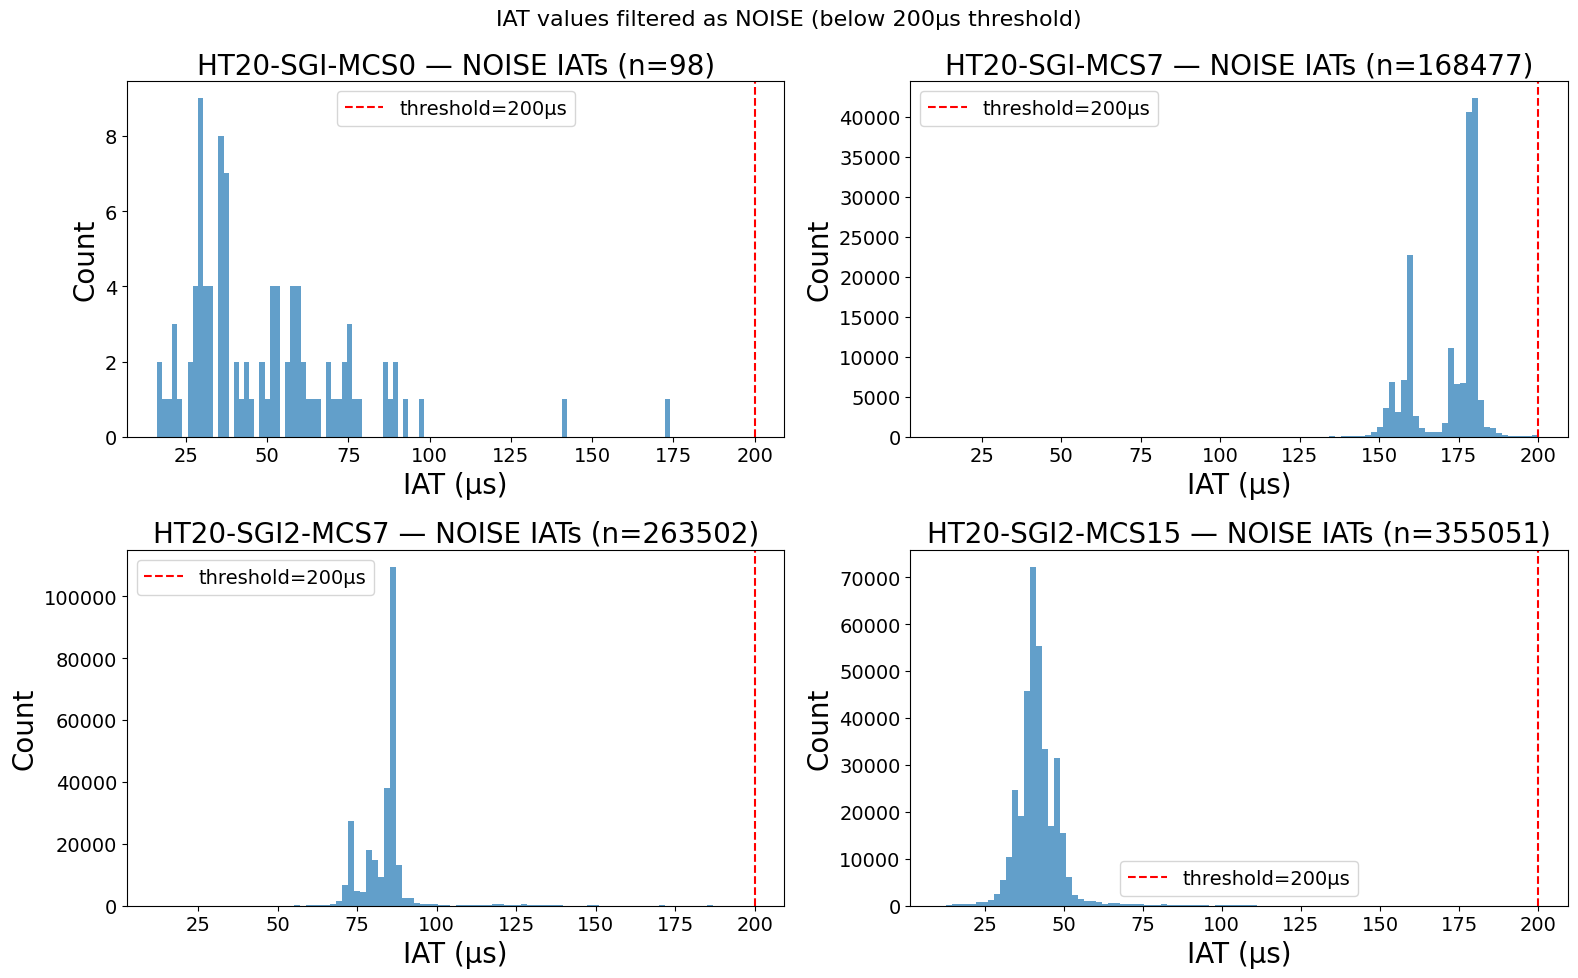


=== NOISE IATs near threshold (150-199µs) — potentially valid measurements ===

  HT20-SGI-MCS0:      1 /     98 NOISE events in 150-199µs range (1.0%)
  HT20-SGI-MCS7: 167005 / 168477 NOISE events in 150-199µs range (99.1%)
  HT20-SGI2-MCS7:   1067 / 263502 NOISE events in 150-199µs range (0.4%)
  HT20-SGI2-MCS15:    147 / 355051 NOISE events in 150-199µs range (0.0%)


In [14]:
recv_df = dfs['tcpaad2']['recv']
noise = recv_df[recv_df['tag'] == 'NOISE']
normal = recv_df[recv_df['tag'] == 'NORMAL']

print(f"=== NOISE events per rate ===\n")
for rate in sorted(recv_df['rate'].unique()):
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    r_all = recv_df[recv_df['rate'] == rate]
    r_noise = noise[noise['rate'] == rate]
    r_normal = normal[normal['rate'] == rate]
    total = len(r_all)
    print(f"{rate_name} (rate={rate}):")
    print(f"  Total RECV: {total}")
    print(f"  NOISE:  {len(r_noise):>8d}  ({len(r_noise)/total*100:5.1f}%)")
    print(f"  NORMAL: {len(r_normal):>8d}  ({len(r_normal)/total*100:5.1f}%)")
    if len(r_noise) > 0:
        iat = r_noise['iat']
        print(f"  NOISE IAT: mean={iat.mean():.0f}µs  median={iat.median():.0f}µs  max={iat.max():.0f}µs  p95={iat.quantile(0.95):.0f}µs")
    if len(r_normal) > 0:
        iat = r_normal['iat_curr']
        print(f"  NORMAL IAT: mean={iat.mean():.0f}µs  median={iat.median():.0f}µs  min={iat.min():.0f}µs")
    print()

# Histogram of NOISE IATs per rate — how close are they to the 200µs threshold?
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for idx, rate in enumerate(sorted(recv_df['rate'].unique())):
    ax = axes[idx // 2][idx % 2]
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    r_noise = noise[noise['rate'] == rate]
    if len(r_noise) > 0:
        ax.hist(r_noise['iat'], bins=100, alpha=0.7, color=PLOT_COLORS[0])
        ax.axvline(x=200, color='red', linestyle='--', label='threshold=200µs')
        ax.set_title(f'{rate_name} — NOISE IATs (n={len(r_noise)})')
        ax.set_xlabel('IAT (µs)')
        ax.set_ylabel('Count')
        ax.legend()
    else:
        ax.set_title(f'{rate_name} — no NOISE events')

plt.suptitle('IAT values filtered as NOISE (below 200µs threshold)', fontsize=16)
plt.tight_layout()
plt.show()

# What fraction of NOISE IATs are close to the threshold (150-199µs)?
print("\n=== NOISE IATs near threshold (150-199µs) — potentially valid measurements ===\n")
for rate in sorted(noise['rate'].unique()):
    rate_name = config.rate_map.get(rate, f'Rate{rate}')
    r = noise[noise['rate'] == rate]
    near = r[(r['iat'] >= 150) & (r['iat'] < 200)]
    print(f"  {rate_name}: {len(near):>6d} / {len(r):>6d} NOISE events in 150-199µs range ({len(near)/len(r)*100:.1f}%)")

In [15]:
dfs['tcpaad2']['recv']['tag'].value_counts()

tag
COLD_START    824587
NOISE         787128
NORMAL         41768
IAT_RESET        653
Name: count, dtype: int64

In [16]:
if __name__ == "__main__":
    normal_events = dfs['tcpaad2']['recv'][dfs['tcpaad2']['recv']['tag'] == 'NORMAL'].copy()
    print(f"Total NORMAL events: {len(normal_events)}")
    
    # Add relative timestamps for each condition's main socket
    normal_events['t_rel_ms'] = np.nan
    
    for rate, bw, delay, iteration in config.conditions:
        recv_df = dfs['tcpaad2']['recv'][
            (dfs['tcpaad2']['recv']['rate'] == rate) &
            (dfs['tcpaad2']['recv']['bw'] == bw) &
            (dfs['tcpaad2']['recv']['delay'] == delay) &
            (dfs['tcpaad2']['recv']['iteration'] == iteration)
        ]
        if recv_df.empty:
            continue
        
        main_sk = recv_df['sk'].value_counts().idxmax()
        t0 = recv_df[recv_df['sk'] == main_sk]['ts'].min()
        
        # Update t_rel_ms for NORMAL events of this main socket
        mask = (normal_events['rate'] == rate) & (normal_events['bw'] == bw) & (normal_events['delay'] == delay) & (normal_events['iteration'] == iteration) & (normal_events['sk'] == main_sk)
        normal_events.loc[mask, 't_rel_ms'] = (normal_events.loc[mask, 'ts'] - t0).dt.total_seconds() * 1000
    rate_filter = 71
    normal_filtered = normal_events[normal_events['rate'] == rate_filter]
    
    print(f"\nNORMAL events for rate {rate_filter} (first 30):")
    display(normal_filtered[['delay', 'iteration', 't_rel_ms', 'iat_curr', 'iat_min', 'ato_us', 'delayed_segs']].head(30))

Total NORMAL events: 41768

NORMAL events for rate 71 (first 30):


,delay,iteration,t_rel_ms,iat_curr,iat_min,ato_us,delayed_segs
28523,nodelay,1,NaN,4732.0,1455.0,3411.0,2.0
28525,nodelay,1,NaN,140.0,1455.0,3411.0,3.0
28534,nodelay,1,NaN,1862.0,1257.0,2112.0,2.0
28535,nodelay,1,NaN,6294.0,1257.0,3774.0,3.0
28550,nodelay,1,NaN,1081.0,768.0,1269.0,2.0
28551,nodelay,1,NaN,3924.0,768.0,2335.0,3.0
28555,nodelay,1,NaN,2076.0,768.0,1642.0,2.0
28559,nodelay,1,NaN,441.0,441.0,661.0,2.0
28665,nodelay,1,22.292,178.0,207.0,850.0,2.0
28708,nodelay,1,27.160,159.0,207.0,335.0,2.0


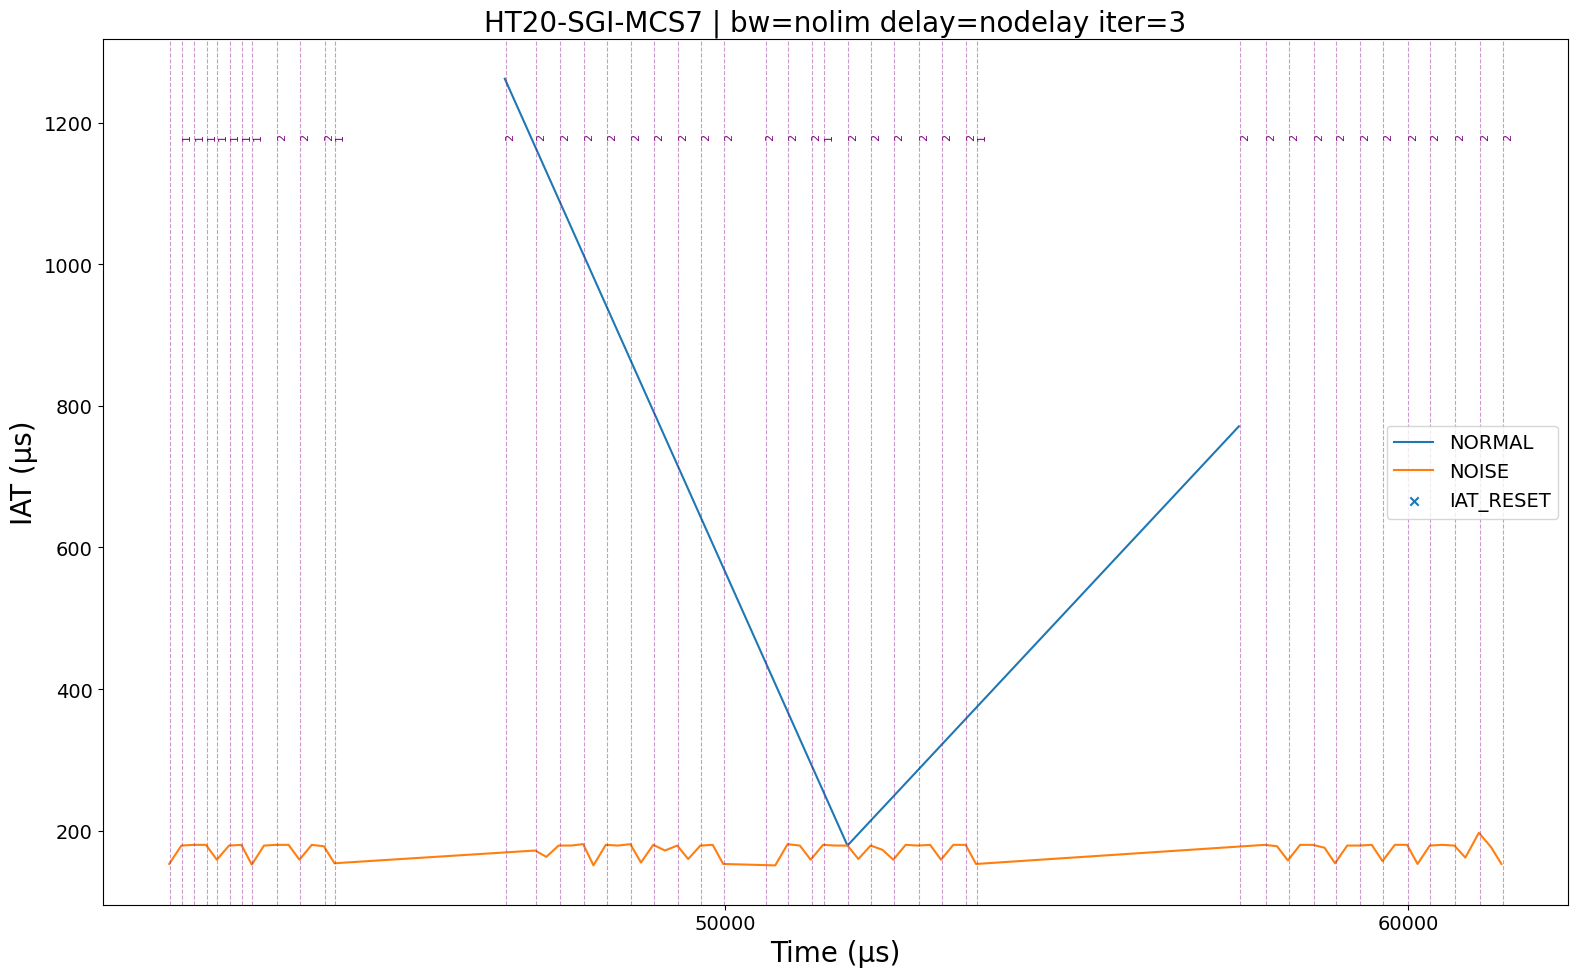

In [17]:
if __name__ == "__main__":
    window_ms = 46.777  # or any other t_rel_ms from above
    
    WINDOW_START_MS = window_ms - 5  # 5ms before
    WINDOW_START_US = WINDOW_START_MS * 1e3
    WINDOW_SIZE_US = 0.02 * 1e6  # 20ms window
    RATE, BW, DELAY, ITER = 71, 'nolim', 'nodelay', 1
    
    # find main socket
    df = dfs['tcpaad2']['recv']
    sel = df[(df['rate']==RATE) & (df['bw']==BW) & (df['delay']==DELAY) & (df['iteration']==ITER)]
    if sel.empty:
        print("Empty", rate, bw, delay, iteration)
    
    main_sk = sel['sk'].value_counts().idxmax()
    sel = sel[sel['sk'] == main_sk]
    t0 = sel['now_us'].min()
    sel['t_rel_us'] = sel['now_us'] - t0
    win = sel[(sel['t_rel_us'] >= WINDOW_START_US) & (sel['t_rel_us'] < WINDOW_START_US + WINDOW_SIZE_US)]
    cold_start = win[win['tag'] == 'COLD_START']
    normal = win[win['tag'] == 'NORMAL']
    noise = win[win['tag'] == 'NOISE']
    reset = win[win['tag'] == 'IAT_RESET']
    
    # --- ACK sent data for same socket & window ---
    ack = dfs['tcpaad2']['ack_sent']
    ack_sk = ack[ack['sk'] == main_sk]
    ack_sk['t_rel_us'] = (ack_sk['ts'] - sel['ts'].min()).dt.total_seconds() * 1e6
    ack_win = ack_sk[(ack_sk['t_rel_us'] >= WINDOW_START_US) & (ack_sk['t_rel_us'] < WINDOW_START_US + WINDOW_SIZE_US)].copy()
    ack_win['delta_bytes'] = ack_win['rcv_nxt'].diff()
    mss = 1448
    
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.xaxis.set_major_locator(plt.MultipleLocator(10000))  # tighter for 100ms window
    
    ax.plot(normal['t_rel_us'], normal['iat_curr'], label='NORMAL')
    ax.plot(noise['t_rel_us'], noise['iat'], label='NOISE')
    ax.scatter(reset['t_rel_us'], reset['iat'], label='IAT_RESET', marker='x')
    
    # --- ACK vertical lines with segment count ---
    for _, row in ack_win.iterrows():
      ax.axvline(row['t_rel_us'], color='purple', alpha=0.4, linestyle='--', linewidth=0.8)
      if pd.notna(row['delta_bytes']) and row['delta_bytes'] > 0:
          segs = int(row['delta_bytes'] / mss)
          ax.text(row['t_rel_us'], ax.get_ylim()[1] * 0.9, str(segs),
                  fontsize=8, rotation=90, color='purple', va='top')
    
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('IAT (µs)')
    # ax.set_yscale('log')
    ax.set_title(f'{config.get_rate_name(71)} | bw=nolim delay=nodelay iter=3')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [18]:
if __name__ == "__main__":
    window_ms = 46.777  # or any other t_rel_ms from above
    
    WINDOW_START_MS = window_ms - 5  # 5ms before
    WINDOW_START_US = WINDOW_START_MS * 1e3
    WINDOW_SIZE_US = 0.02 * 1e6  # 20ms window
    RATE, BW, DELAY, ITER = 71, 'nolim', 'nodelay', 1
    
    # find main socket
    df = dfs['tcpaad2']['recv']
    sel = df[(df['rate']==RATE) & (df['bw']==BW) & (df['delay']==DELAY) & (df['iteration']==ITER)]
    main_sk = sel['sk'].value_counts().idxmax()
    t0 = sel[sel['sk'] == main_sk]['ts'].min()
    
    def make_log(event_name):
        sub = dfs['tcpaad2'][event_name]
        sub = sub[(sub['rate']==RATE) & (sub['bw']==BW) & (sub['delay']==DELAY) & (sub['iteration']==ITER)]
        sub = sub[sub['sk'] == main_sk].copy()
        sub['t_rel_us'] = (sub['ts'] - t0).dt.total_seconds() * 1e6
        sub = sub[(sub['t_rel_us'] >= WINDOW_START_US) & (sub['t_rel_us'] < WINDOW_START_US + WINDOW_SIZE_US)]
        sub['event'] = event_name
        return sub
    
    all_logs = pd.concat([make_log(ev) for ev in EVENTS], ignore_index=True)
    all_logs['ack_trigger'] = ''
    for i in all_logs.index:
        if all_logs.loc[i, 'event'] != 'ack_sent':
            continue
        ack_rcv_nxt = all_logs.loc[i, 'rcv_nxt']
        for j in range(i - 1, -1, -1):
            row_j = all_logs.loc[j]
            ev = row_j['event']
            # skip events with different rcv_nxt
            if pd.notna(row_j.get('rcv_nxt')) and row_j['rcv_nxt'] != ack_rcv_nxt:
                continue
            if ev == 'sched':
                all_logs.loc[i, 'ack_trigger'] = 'TIMER_SCHED'
                break
            elif ev == 'timer_fired':
                all_logs.loc[i, 'ack_trigger'] = 'TIMER_EXPIRED'
                break
            elif ev == 'ack_chk' and row_j['outcome'] == 'SEND_NOW':
                all_logs.loc[i, 'ack_trigger'] = row_j['reason']
                break
    
    all_logs = all_logs.sort_values('t_rel_us').reset_index(drop=True)
    
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 200)
    Path('tmp').mkdir(exist_ok=True)
    all_logs.to_csv('tmp/event_log_albert.csv', index=False)
    from IPython.display import display, HTML
    html = all_logs.to_html()
    display(HTML(f'<div style="font-size:10px; overflow-x:auto">{html}</div>'))

,kernel,rate,bw,delay,iteration,ts,sk,now_us,seq,end_seq,tag,iat_curr,iat_min,ato_us,ato_jiffies,delayed_segs,old_iat_min,len,iat,threshold,t_rel_us,event,rcv_nxt,outcome,ofo,bytes,mss,quick,pingpong,pending,ato,reason,reason_two_seg,reason_quick,reason_ack_now,reason_comp_limit,reason_dup_ack,timeout_us,ato_before,ato_after,ack_trigger
0,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510663+05:00,000000001367416d,831508035.0,3.839052e+09,3.839053e+09,NOISE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,153.0,200.0,41865.0,recv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
1,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510666+05:00,000000001367416d,831508035.0,3.839052e+09,3.839053e+09,COLD_START,NaN,NaN,500000.0,NaN,0.0,NaN,1448.0,NaN,NaN,41868.0,recv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
2,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510670+05:00,000000001367416d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,41872.0,ack_chk,3.839053e+09,ENTRY,1.0,1448.0,1448.0,1.0,0.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
3,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510673+05:00,000000001367416d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41875.0,ack_chk,3.839053e+09,SEND_NOW,NaN,NaN,1448.0,1.0,0.0,1,NaN,QUICK,False,True,False,False,False,NaN,NaN,NaN,
4,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510676+05:00,000000001367416d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41878.0,ack_sent,3.839053e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QUICK
5,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510842+05:00,000000001367416d,831508214.0,3.839053e+09,3.839055e+09,NOISE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.0,200.0,42044.0,recv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
6,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510845+05:00,000000001367416d,831508214.0,3.839053e+09,3.839055e+09,COLD_START,NaN,NaN,500000.0,NaN,0.0,NaN,1448.0,NaN,NaN,42047.0,recv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
7,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510849+05:00,000000001367416d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,42051.0,ack_chk,3.839055e+09,ENTRY,1.0,1448.0,1448.0,1.0,0.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
8,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510852+05:00,000000001367416d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42054.0,ack_chk,3.839055e+09,SEND_NOW,NaN,NaN,1448.0,1.0,0.0,5,NaN,QUICK,False,True,False,False,False,NaN,NaN,NaN,
9,tcpaad2,71,nolim,nodelay,1,2026-03-17 03:17:09.510855+05:00,000000001367416d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42057.0,ack_sent,3.839055e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QUICK


In [19]:
if __name__ == "__main__":
    phy_rates = {64: 7.2, 71: 72.2, 199: 150, 215: 300}
    
    df = dfs['tcpaad2']['recv']
    for (rate, bw, delay, iteration) in config.conditions:
        if delay != 'nodelay':
            continue
        sel = df[(df['rate']==rate) & (df['bw']==bw) & (df['delay']==delay) & (df['iteration']==iteration)]
        if sel.empty:
          continue
        main_sk = sel['sk'].value_counts().idxmax()
        normal = sel[(sel['sk'] == main_sk) & (sel['tag'] == 'NORMAL')]
        if normal.empty:
          continue
        
        seg_size = (normal['end_seq'] - normal['seq']).median()
        expected_us = seg_size * 8 / phy_rates[rate]
        actual_min = normal['iat_min'].min()
        median_min = normal['iat_min'].median()
        
        print(f'{config.get_rate_name(rate):20s} bw={bw:5s} delay={delay:7s} iter={iteration} | '
              f'expected={expected_us:7.0f}µs  iat_min_min={actual_min:5.0f}µs  iat_min_median={median_min:7.0f}µs '
              f'ratio={actual_min/expected_us:.2f}')

HT20-SGI-MCS0        bw=nolim delay=nodelay iter=1 | expected=   1609µs  iat_min_min=  848µs  iat_min_median=   1577µs ratio=0.53
HT20-SGI-MCS0        bw=nolim delay=nodelay iter=2 | expected=   1609µs  iat_min_min=  717µs  iat_min_median=   1551µs ratio=0.45
HT20-SGI-MCS0        bw=nolim delay=nodelay iter=3 | expected=   1609µs  iat_min_min=  935µs  iat_min_median=   1539µs ratio=0.58
HT20-SGI-MCS7        bw=nolim delay=nodelay iter=1 | expected=    160µs  iat_min_min=  201µs  iat_min_median=    201µs ratio=1.25
HT20-SGI-MCS7        bw=nolim delay=nodelay iter=2 | expected=    160µs  iat_min_min=  201µs  iat_min_median=    201µs ratio=1.25
HT20-SGI-MCS7        bw=nolim delay=nodelay iter=3 | expected=    160µs  iat_min_min=  201µs  iat_min_median=    201µs ratio=1.25
HT20-SGI2-MCS7       bw=nolim delay=nodelay iter=1 | expected=     77µs  iat_min_min=  203µs  iat_min_median=    236µs ratio=2.63
HT20-SGI2-MCS7       bw=nolim delay=nodelay iter=2 | expected=     77µs  iat_min_min=  203